In [22]:
import pandas as pd
import matplotlib.pyplot as mpl

df = pd.read_csv('ne_code_file1.csv').dropna(subset='ne_code')
df['label'] = df['label'].str.lower()
df['ne_code'] = df['ne_code'].apply(lambda code: 'item' if code.endswith('item') else code)
df

,token,label,score,selection_freq,code,other_variety,note,ne_code,notes
74,wien❤️,at,0.930604,0.10,NE,NaN,NaN,place,NaN
75,krems/stein/mautern,at,0.917586,0.10,NE,NaN,NaN,place,NaN
76,linz/umgebung,at,0.885676,0.10,NE,NaN,NaN,place,NaN
77,klagenfurt?🙈,at,0.855934,0.10,NE,NaN,NaN,place,NaN
78,österreichsollösterreichbleiben,at,0.815841,0.10,NE,NaN,NaN,place,NaN
...,...,...,...,...,...,...,...,...,...
244,moerserin,de_s,0.863284,0.10,NE,NaN,NaN,person,NaN
245,schwabing,de_s,0.862512,0.10,NE,NaN,NaN,place,NaN
246,fürth-unterfarrnbach,de_s,0.861769,0.10,NE,NaN,NaN,place,NaN
247,aachenerstudentin,de_s,0.861307,0.10,NE,NaN,NaN,person,NaN


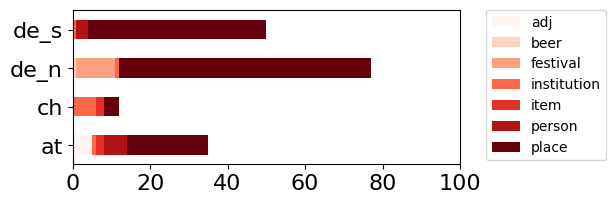

In [26]:
display_data = (df
    .groupby(['label', 'ne_code'])
    .size()
    .reset_index()
    .rename(columns={0:'count'})
    .sort_values('label')
    .pivot(index='label', columns='ne_code', values='count')
)
g = display_data.plot(
    kind='barh', 
    stacked=True, 
    xlim=(0, 100),
    colormap='Reds',
    figsize=(5, 2),
    ylabel=None, 
    fontsize=16,
)
g.set(ylabel=None)
g.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05)).figure.savefig('beeronym-plot.pdf', bbox_inches='tight')